<a href="https://colab.research.google.com/github/Pooja-V15/NVIDIA-AI-ML-Internship/blob/main/day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np


In [ ]:
inputs = np.array([1, 2, 3])
weights = np.array([0.2, 0.8, -0.5])
bias = 2
output = np.dot(inputs, weights) + bias
print("Neuron Output:", output)

Neuron Output: 2.3


In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = 2

print("Sigmoid Output:", sigmoid(x))

Sigmoid Output: 0.8807970779778823


In [ ]:
from sklearn.neural_network import MLPClassifier

# XOR Dataset
X = [[0,0],
     [0,1],
     [1,0],
     [1,1]]

y = [0,1,1,0]

# Neural Network
model = MLPClassifier(hidden_layer_sizes=(4,),
                      max_iter=5000,
                      random_state=42)

model.fit(X, y)

print("Predictions:")
print(model.predict(X))

Predictions:
[0 0 0 0]


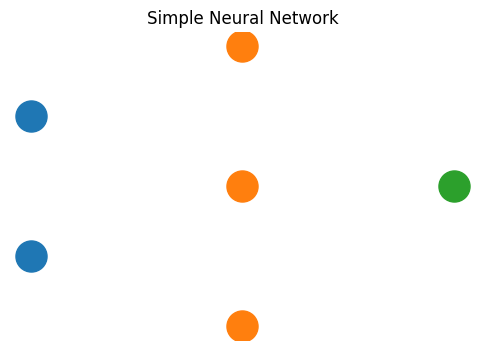

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Input Layer
plt.scatter([1,1],[1,2],s=500)

# Hidden Layer
plt.scatter([3,3,3],[0.5,1.5,2.5],s=500)

# Output Layer
plt.scatter([5],[1.5],s=500)

plt.title("Simple Neural Network")
plt.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: []


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Load Fashion-MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model on GPU
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_classes))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_classes))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7775 - loss: 0.6228 - val_accuracy: 0.8497 - val_loss: 0.4210
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8447 - loss: 0.4247 - val_accuracy: 0.8671 - val_loss: 0.3652
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8584 - loss: 0.3841 - val_accuracy: 0.8685 - val_loss: 0.3626
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8694 - loss: 0.3571 - val_accuracy: 0.8787 - val_loss: 0.3367
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8729 - loss: 0.3419 - val_accuracy: 0.8764 - val_loss: 0.3331
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8785 - loss: 0.3255 - val_accuracy: 0.8761 - val_loss: 0.3411
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8861 - loss: 0.3112 - val_accuracy: 0.8831 - val_loss: 0.3250
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8871 - loss: 0.3020 - val_accuracy: 0

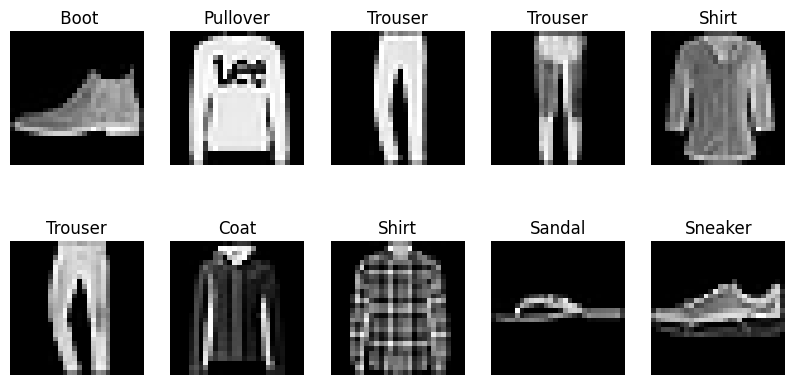

In [ ]:
class_names = [
    'T-shirt','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag',' Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found ZIP: /content/archive.zip
Dataset extracted successfully!
Dataset Path: /content/intel_dataset/seg_train/seg_train
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.5481 - loss: 1.1247 - val_accuracy: 0.6639 - val_loss: 0.9204
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6871 - loss: 0.8309 - val_accuracy: 0.7684 - val_loss: 0.6494
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7518 - loss: 0.7015 - val_accuracy: 0.7969 - val_loss: 0.5550
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7839 - loss: 0.6041 - val_accuracy: 0.8061 - val_loss: 0.5215
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8143 - loss: 0.5215 - val_accuracy: 0.8133 - val_loss: 0.5255
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8381 - loss: 0.4552 - val_accuracy: 0.8350 - val_loss: 0.4681
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8644 - loss: 0.3903 - val_accuracy: 0.8104 - val_loss: 0.5431
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8792 - loss: 0.3326 - val_acc

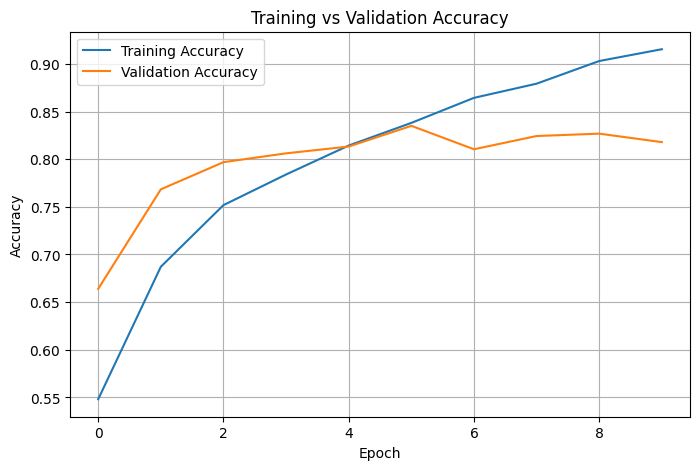

Model saved successfully!


In [ ]:
import os
import zipfile
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# =====================================
# Find uploaded ZIP file automatically
# =====================================
zip_files = [f for f in os.listdir('/content') if f.endswith('.zip')]

if not zip_files:
    raise FileNotFoundError("No ZIP file found in /content")

zip_path = os.path.join('/content', zip_files[0])
print("Found ZIP:", zip_path)

# =====================================
# Extract ZIP
# =====================================
extract_path = "/content/intel_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# =====================================
# Find training folder automatically
# =====================================
train_dir = None

for root, dirs, files in os.walk(extract_path):
    if "buildings" in dirs:
        train_dir = root
        break

if train_dir is None:
    raise Exception(
        "Dataset structure not found. Please check extracted folders."
    )

print("Dataset Path:", train_dir)

# =====================================
# Load Dataset
# =====================================
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================================
# CNN Model
# =====================================
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(150,150,3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =====================================
# Train Model
# =====================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================
# Evaluate
# =====================================
loss, accuracy = model.evaluate(val_ds)

print("\nValidation Accuracy:", accuracy)

# =====================================
# Plot Accuracy
# =====================================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# =====================================
# Save Model
# =====================================
model.save('/content/intel_image_classifier.h5')

print("Model saved successfully!")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('/content/collegePlace.csv')

# Remove missing values
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print(df.columns)

# Change target column if needed
target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Index(['Age', 'Gender', 'Stream', 'Internships', 'CGPA', 'Hostel',
       'HistoryOfBacklogs', 'PlacedOrNot'],
      dtype='object')
Accuracy: 0.8737373737373737


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, median_absolute_error

sns.set(style='whitegrid')
%matplotlib inline

print('PyTorch version:', torch.__version__)


PyTorch version: 2.11.0+cu128


In [ ]:
# Device configuration (GPU usage)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using CUDA GPU:', torch.cuda.get_device_name(0))
else:
    # For DGX, this should be CUDA. Fallback is provided only to keep the notebook runnable elsewhere.
    device = torch.device('cpu')
    print('CUDA GPU not detected. Using CPU (for full demo, run on a DGX with GPUs).')


Using CUDA GPU: Tesla T4


In [ ]:
# Hyperparameters for the autoregressive task
SEQ_LEN = 64        # number of pixels used per image (first SEQ_LEN values of the flattened image)
INPUT_DIM = SEQ_LEN - 1
BATCH_SIZE = 512
VALIDATION_SPLIT = 0.1
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [ ]:
transform = transforms.ToTensor()

full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
print('Number of training samples in raw MNIST:', len(full_train))

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 446kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

Number of training samples in raw MNIST: 60000


In [ ]:
class AutoregressiveMNIST(Dataset):
    """Wraps MNIST to create (input_sequence, target_value) pairs.

    - input_sequence: first SEQ_LEN-1 flattened pixel values
    - target_value: SEQ_LEN-th pixel value (treated as missing and to be predicted)
    """
    def __init__(self, base_dataset, seq_len=64):
        self.base_dataset = base_dataset
        self.seq_len = seq_len

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]   # ignore label
        # img: (1, 28, 28), values in [0,1]
        flat = img.view(-1)               # 784-length vector
        flat = flat[:self.seq_len]
        x = flat[:-1]                     # input sequence (T-1)
        y = flat[-1]                      # target (T-th element)
        return x, y

# Create autoregressive dataset
ar_dataset = AutoregressiveMNIST(full_train, seq_len=SEQ_LEN)
print('Autoregressive dataset size:', len(ar_dataset))


Autoregressive dataset size: 60000


In [ ]:
# Train/validation split

num_samples = len(ar_dataset)
indices = np.arange(num_samples)
np.random.shuffle(indices)

val_size = int(VALIDATION_SPLIT * num_samples)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_subset = torch.utils.data.Subset(ar_dataset, train_indices)
val_subset = torch.utils.data.Subset(ar_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Train samples: {len(train_subset)}, Validation samples: {len(val_subset)}')


Train samples: 54000, Validation samples: 6000


In [ ]:
class DeepAutoregressiveNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        hidden_dims = [512, 512, 256, 256, 128, 128, 64, 64]
        assert len(hidden_dims) == 8, 'We expect exactly 8 hidden layers.'

        self.fc_in = nn.Linear(input_dim, hidden_dims[0])
        self.fcs = nn.ModuleList()
        for i in range(len(hidden_dims) - 1):
            self.fcs.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
        self.fc_out = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        # x: (batch_size, input_dim)
        x = self.fc_in(x)
        x = F.relu(x)
        for fc in self.fcs:
            x = fc(x)
            x = F.relu(x)
        x = self.fc_out(x)
        return x.squeeze(-1)  # return shape (batch_size,)


model = DeepAutoregressiveNet(INPUT_DIM).to(device)
print(model)


DeepAutoregressiveNet(
  (fc_in): Linear(in_features=63, out_features=512, bias=True)
  (fcs): ModuleList(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): Linear(in_features=64, out_features=64, bias=True)
  )
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
# Training hyperparameters
LR = 1e-3
NUM_EPOCHS = 15

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []


In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = F.mse_loss(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_samples += x.size(0)
    return total_loss / total_samples


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            loss = F.mse_loss(preds, y)

            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)

            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())
    avg_loss = total_loss / total_samples
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return avg_loss, all_preds, all_targets


In [ ]:
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_preds, val_targets = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')


Epoch 01/15 | Train Loss: 0.000350 | Val Loss: 0.000652
Epoch 02/15 | Train Loss: 0.000348 | Val Loss: 0.000624
Epoch 03/15 | Train Loss: 0.000293 | Val Loss: 0.000570
Epoch 04/15 | Train Loss: 0.000200 | Val Loss: 0.000492
Epoch 05/15 | Train Loss: 0.000159 | Val Loss: 0.000476
Epoch 06/15 | Train Loss: 0.000166 | Val Loss: 0.000516
Epoch 07/15 | Train Loss: 0.000167 | Val Loss: 0.000446
Epoch 08/15 | Train Loss: 0.000222 | Val Loss: 0.000545
Epoch 09/15 | Train Loss: 0.000152 | Val Loss: 0.000522
Epoch 10/15 | Train Loss: 0.000217 | Val Loss: 0.000767
Epoch 11/15 | Train Loss: 0.000219 | Val Loss: 0.000460
Epoch 12/15 | Train Loss: 0.000223 | Val Loss: 0.000449
Epoch 13/15 | Train Loss: 0.000165 | Val Loss: 0.000454
Epoch 14/15 | Train Loss: 0.000231 | Val Loss: 0.000450
Epoch 15/15 | Train Loss: 0.000147 | Val Loss: 0.000445


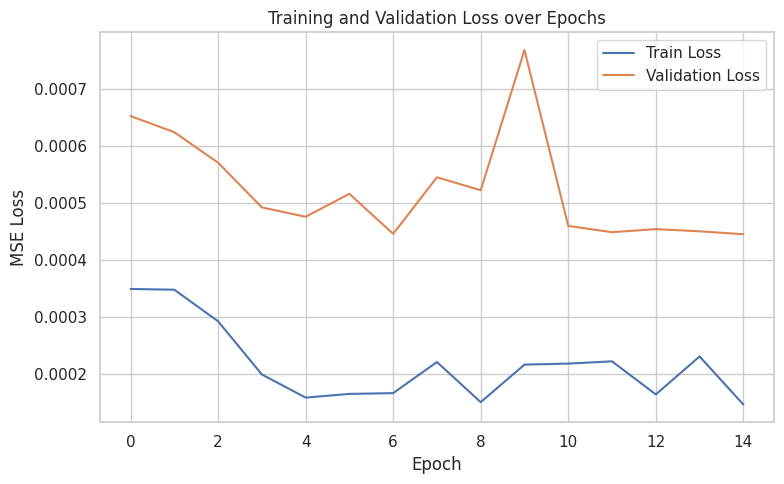

In [ ]:
# Plot loss curves
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Compute metrics using the latest val_preds and val_targets

mse = mean_squared_error(val_targets, val_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(val_targets, val_preds)
med_ae = median_absolute_error(val_targets, val_preds)
r2 = r2_score(val_targets, val_preds)
ev = explained_variance_score(val_targets, val_preds)

print('Validation metrics:')
print(f'  MSE   : {mse:.8f}')
print(f'  RMSE  : {rmse:.8f}')
print(f'  MAE   : {mae:.8f}')
print(f'  MedAE : {med_ae:.8f}')
print(f'  R^2   : {r2:.6f}')
print(f'  ExpVar: {ev:.6f}')


Validation metrics:
  MSE   : 0.00044528
  RMSE  : 0.02110174
  MAE   : 0.00152269
  MedAE : 0.00079103
  R^2   : 0.314719
  ExpVar: 0.314780


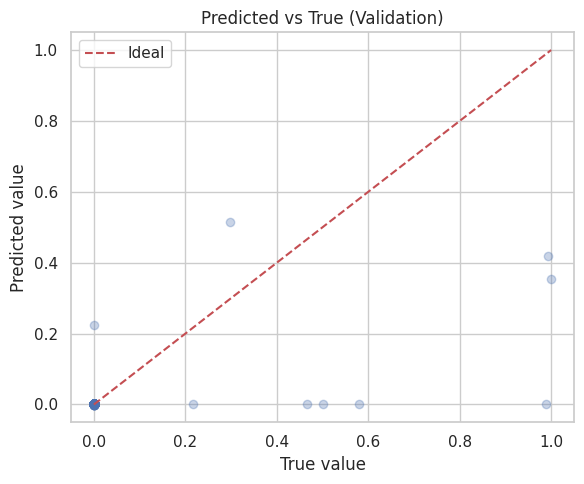

In [ ]:
# Predicted vs true scatter
plt.figure(figsize=(6,5))
plt.scatter(val_targets, val_preds, alpha=0.3)
min_v = min(val_targets.min(), val_preds.min())
max_v = max(val_targets.max(), val_preds.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='Ideal')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.title('Predicted vs True (Validation)')
plt.legend()
plt.tight_layout()
plt.show()


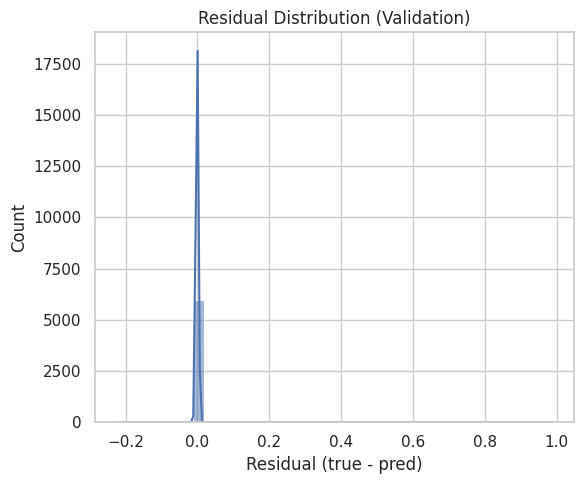

In [ ]:
# Residual distribution
residuals = val_targets - val_preds

plt.figure(figsize=(6,5))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel('Residual (true - pred)')
plt.title('Residual Distribution (Validation)')
plt.tight_layout()
plt.show()


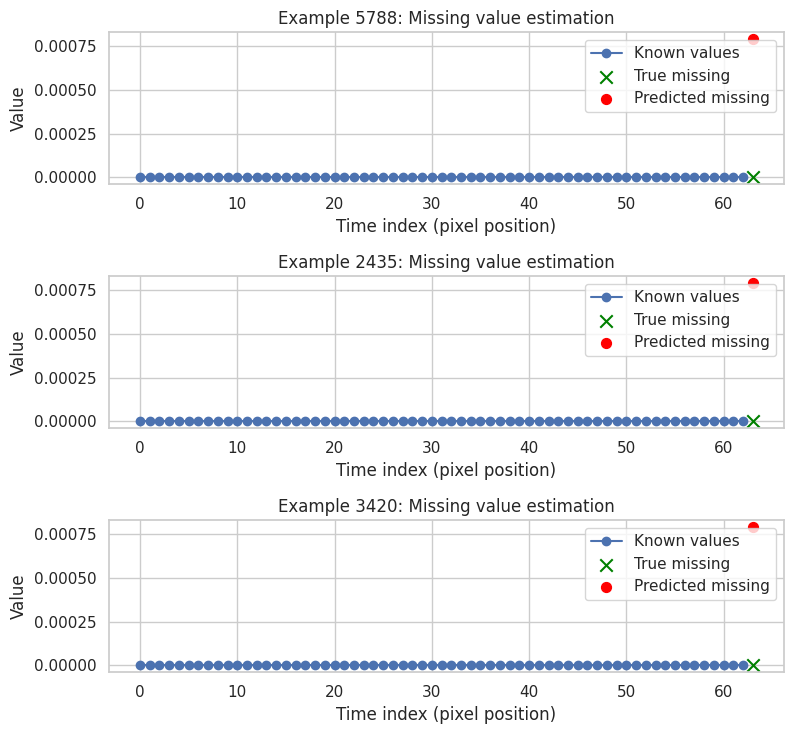

In [ ]:
# Example sequence visualization for a few samples

num_examples = 3
indices = np.random.choice(len(val_subset), size=num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(8, 2.5 * num_examples))
if num_examples == 1:
    axes = [axes]

model.eval()
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        x, y_true = val_subset[idx]
        x_tensor = x.unsqueeze(0).to(device)
        y_pred = model(x_tensor).item()

        # Plot input sequence and mark true vs predicted missing value
        seq = x.numpy()
        ax.plot(range(len(seq)), seq, marker='o', label='Known values')
        ax.scatter(len(seq), y_true.item(), color='green', marker='x', s=80, label='True missing')
        ax.scatter(len(seq), y_pred, color='red', marker='o', s=50, label='Predicted missing')
        ax.set_xlabel('Time index (pixel position)')
        ax.set_ylabel('Value')
        ax.set_title(f'Example {idx}: Missing value estimation')
        ax.legend(loc='best')

plt.tight_layout()
plt.show()


In [ ]:
def compute_saliency_for_samples(model, dataset, device, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    saliency_list = []
    inputs_list = []
    targets_list = []
    preds_list = []

    for idx in indices:
        x, y = dataset[idx]
        x = x.to(device)
        y = torch.tensor(y, device=device)

        x = x.unsqueeze(0)  # batch dimension
        x.requires_grad_(True)

        output = model(x)  # scalar per batch element
        score = output.squeeze()  # treat as score (not MSE here)
        model.zero_grad()
        if x.grad is not None:
            x.grad.zero_()
        score.backward()

        saliency = x.grad.detach().abs().cpu().numpy()[0]
        saliency_list.append(saliency)
        inputs_list.append(x.detach().cpu().numpy()[0])
        targets_list.append(y.item())
        preds_list.append(output.detach().cpu().item())

    return indices, np.array(inputs_list), np.array(targets_list), np.array(preds_list), np.array(saliency_list)


In [ ]:
# Compute saliency maps for a few validation samples

num_saliency_samples = 5
indices, sal_inputs, sal_targets, sal_preds, saliencies = compute_saliency_for_samples(
    model, val_subset, device, num_samples=num_saliency_samples
)

print('Saliency computed for indices:', indices)


Saliency computed for indices: [5975 3898 3476  371 5343]


/tmp/ipykernel_723/2358423873.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, device=device)


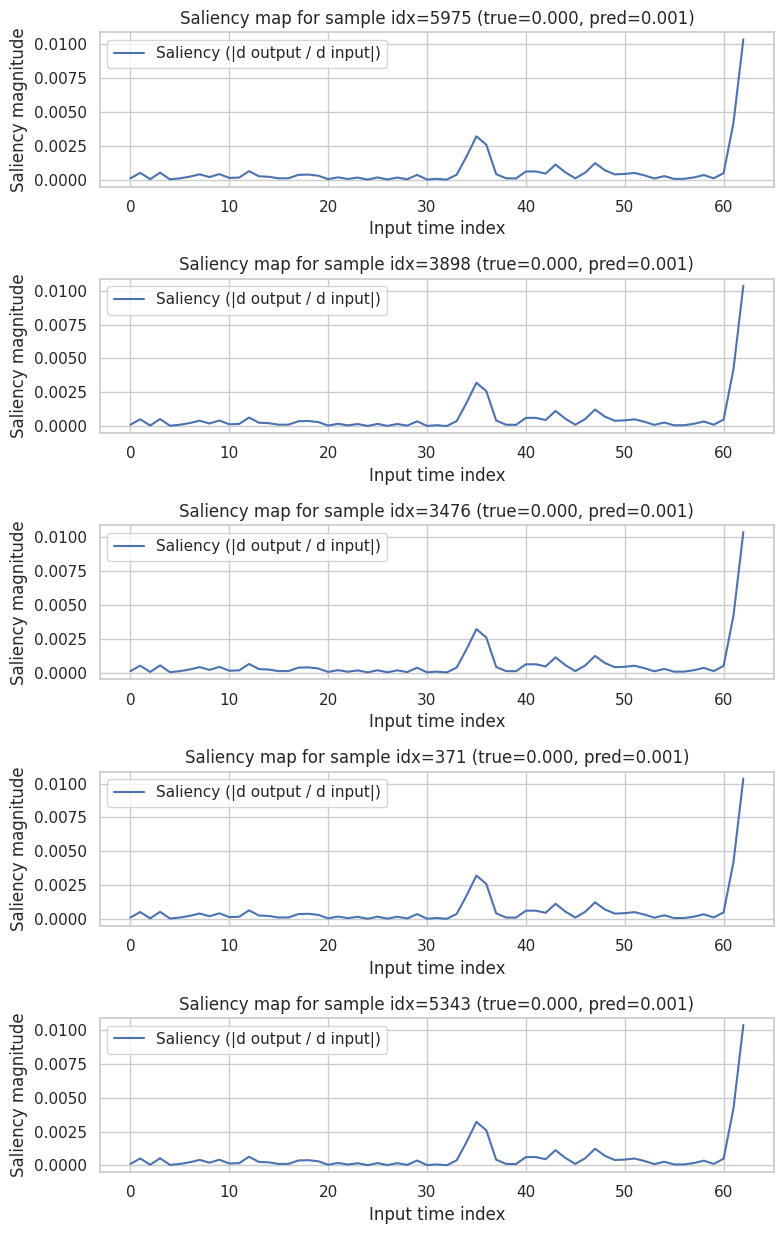

In [ ]:
# Plot saliency maps

fig, axes = plt.subplots(num_saliency_samples, 1, figsize=(8, 2.5 * num_saliency_samples))
if num_saliency_samples == 1:
    axes = [axes]

for i in range(num_saliency_samples):
    ax = axes[i]
    ax.plot(saliencies[i], label='Saliency (|d output / d input|)')
    ax.set_xlabel('Input time index')
    ax.set_ylabel('Saliency magnitude')
    ax.set_title(f'Saliency map for sample idx={indices[i]} (true={sal_targets[i]:.3f}, pred={sal_preds[i]:.3f})')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()


Saving StudentsPerformance.csv to StudentsPerformance (1).csv
Dataset Shape: (1000, 8)

First 5 Rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

R2 Score: 0.8528
MAE: 4.63
RMSE: 5.98


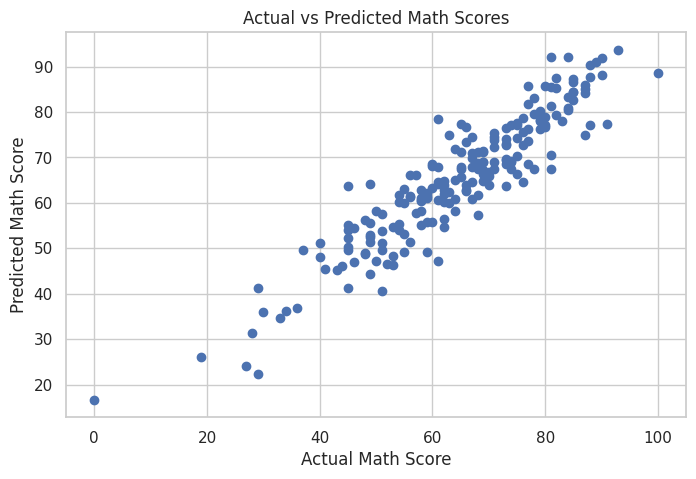


Example Prediction:
Predicted Math Score: 70.0
Actual Math Score: 72


In [ ]:
# ==========================================
# STUDENTS PERFORMANCE IN EXAMS
# Regression: Predict Math Score
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# Upload Dataset
# ==========================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# ==========================================
# Features and Target
# ==========================================

target = "math score"

X = df.drop(target, axis=1)
y = df[target]

# ==========================================
# Identify Categorical Columns
# ==========================================

categorical_cols = X.select_dtypes(include=["object"]).columns

# ==========================================
# Preprocessing
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

# ==========================================
# Model Pipeline
# ==========================================

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Train Model
# ==========================================

model.fit(X_train, y_train)

# ==========================================
# Predictions
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Evaluation
# ==========================================

print("\nR2 Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

# ==========================================
# Actual vs Predicted Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Scores")
plt.grid(True)
plt.show()

# ==========================================
# Example Prediction
# ==========================================

sample = X.iloc[[0]]

prediction = model.predict(sample)

print("\nExample Prediction:")
print("Predicted Math Score:", round(prediction[0], 2))
print("Actual Math Score:", y.iloc[0])

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

sns.set(style='whitegrid')
%matplotlib inline

print('PyTorch version:', torch.__version__)

# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using CUDA GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device('cpu')
    print('CUDA GPU not detected. Using CPU (for full demo, run on a DGX with GPUs).')


PyTorch version: 2.11.0+cu128
Using CUDA GPU: Tesla T4


In [2]:
# Hyperparameters
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.1
RANDOM_SEED = 42
NUM_CLASSES = 10

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Data transforms: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# CIFAR-10 training and test datasets
train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print('Full train size:', len(train_full))
print('Test size      :', len(test_dataset))


100%|██████████| 170M/170M [00:04<00:00, 34.6MB/s]


Full train size: 50000
Test size      : 10000


In [3]:
# Split train into train/validation

val_size = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Train size:', len(train_dataset))
print('Val size  :', len(val_dataset))


Train size: 45000
Val size  : 5000


In [4]:
class DeepCIFARNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Convolutional feature extractor
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32x32 -> 16x16
            nn.Dropout(0.25),
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 16x16 -> 8x8
            nn.Dropout(0.25),
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 8x8 -> 4x4
            nn.Dropout(0.25),
        )

        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.out = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.5, training=self.training)
        logits = self.out(x)
        return logits


model = DeepCIFARNet(num_classes=NUM_CLASSES).to(device)
print(model)


DeepCIFARNet(
  (conv_block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_si

In [5]:
LR = 1e-3
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []


In [6]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    total_samples = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
    return running_loss / total_samples


def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    total_samples = 0
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            all_logits.append(logits.detach().cpu())
            all_targets.append(labels.detach().cpu())
    avg_loss = running_loss / total_samples
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    return avg_loss, all_logits, all_targets


In [7]:
# Main training loop

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_logits, val_targets = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')


Epoch 01/20 | Train Loss: 1.6623 | Val Loss: 1.2876
Epoch 02/20 | Train Loss: 1.2111 | Val Loss: 1.0627
Epoch 03/20 | Train Loss: 0.9883 | Val Loss: 0.8967
Epoch 04/20 | Train Loss: 0.8693 | Val Loss: 0.8272
Epoch 05/20 | Train Loss: 0.7710 | Val Loss: 0.7420
Epoch 06/20 | Train Loss: 0.7020 | Val Loss: 0.6279
Epoch 07/20 | Train Loss: 0.6343 | Val Loss: 0.6324
Epoch 08/20 | Train Loss: 0.5947 | Val Loss: 0.5432
Epoch 09/20 | Train Loss: 0.5501 | Val Loss: 0.5163
Epoch 10/20 | Train Loss: 0.5059 | Val Loss: 0.5321
Epoch 11/20 | Train Loss: 0.4725 | Val Loss: 0.5154
Epoch 12/20 | Train Loss: 0.4504 | Val Loss: 0.4996
Epoch 13/20 | Train Loss: 0.4153 | Val Loss: 0.4695
Epoch 14/20 | Train Loss: 0.3954 | Val Loss: 0.4577
Epoch 15/20 | Train Loss: 0.3696 | Val Loss: 0.4870
Epoch 16/20 | Train Loss: 0.3480 | Val Loss: 0.5619
Epoch 17/20 | Train Loss: 0.3258 | Val Loss: 0.4929
Epoch 18/20 | Train Loss: 0.3137 | Val Loss: 0.4934
Epoch 19/20 | Train Loss: 0.2894 | Val Loss: 0.4715
Epoch 20/20 

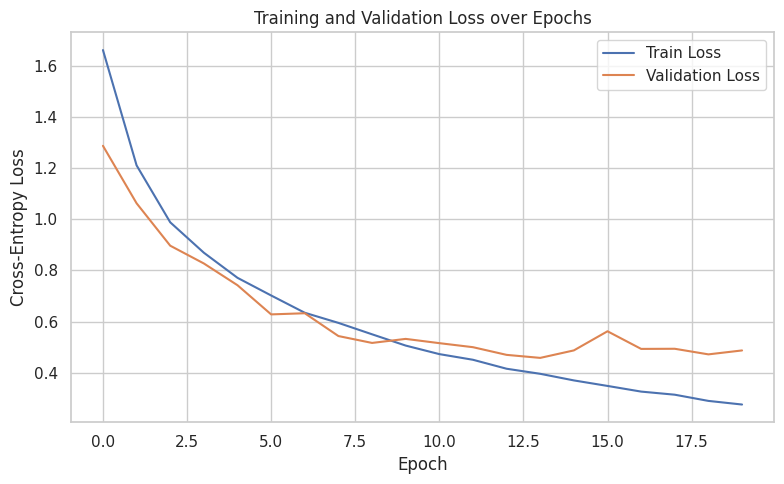

In [8]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Get logits and targets for train and test for later ROC/PR analysis
train_loss_final, train_logits, train_targets = evaluate(model, train_loader, device)
print(f"Final train loss: {train_loss_final:.4f}")

test_loss, test_logits, test_targets = evaluate(model, test_loader, device)
print(f"Test loss: {test_loss:.4f}")

# Convert logits to probabilities and predictions
train_probs = F.softmax(train_logits, dim=1).numpy()
train_y_true = train_targets.numpy()

test_probs = F.softmax(test_logits, dim=1).numpy()
test_y_true = test_targets.numpy()

test_y_pred = np.argmax(test_probs, axis=1)

print('Test set size:', len(test_y_true))


Final train loss: 0.1902
Test loss: 0.5271
Test set size: 10000


In [10]:
def compute_classification_metrics(y_true, y_pred, y_proba, num_classes):
    # macro-averaged precision, recall, f1
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    # Multiclass ROC AUC (macro one-vs-rest)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc_macro = roc_auc_score(y_true_bin, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        auc_macro = np.nan

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'mcc': mcc,
        'kappa': kappa,
        'auc_macro': auc_macro,
    }


def bootstrap_metrics(y_true, y_pred, y_proba, num_classes, n_bootstrap=50, seed=123):
    rng = np.random.RandomState(seed)
    metrics_list = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        m = compute_classification_metrics(y_true[idx], y_pred[idx], y_proba[idx], num_classes)
        metrics_list.append(m)
    return metrics_list


metrics_boot = bootstrap_metrics(test_y_true, test_y_pred, test_probs, NUM_CLASSES, n_bootstrap=50)

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'kappa', 'auc_macro']

print('Bootstrap mean ± variance of metrics (test set):')
for name in metric_names:
    vals = np.array([m[name] for m in metrics_boot])
    print(f"{name:9s}: mean = {vals.mean():.4f}, var = {vals.var():.6f}")


Bootstrap mean ± variance of metrics (test set):
accuracy : mean = 0.8425, var = 0.000011
precision: mean = 0.8485, var = 0.000011
recall   : mean = 0.8426, var = 0.000010
f1       : mean = 0.8408, var = 0.000011
mcc      : mean = 0.8260, var = 0.000013
kappa    : mean = 0.8250, var = 0.000013
auc_macro: mean = 0.9860, var = 0.000000


In [11]:
def compute_classification_metrics(y_true, y_pred, y_proba, num_classes):
    # macro-averaged precision, recall, f1
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    # Multiclass ROC AUC (macro one-vs-rest)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc_macro = roc_auc_score(y_true_bin, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        auc_macro = np.nan

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'mcc': mcc,
        'kappa': kappa,
        'auc_macro': auc_macro,
    }


def bootstrap_metrics(y_true, y_pred, y_proba, num_classes, n_bootstrap=50, seed=123):
    rng = np.random.RandomState(seed)
    metrics_list = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        m = compute_classification_metrics(y_true[idx], y_pred[idx], y_proba[idx], num_classes)
        metrics_list.append(m)
    return metrics_list


metrics_boot = bootstrap_metrics(test_y_true, test_y_pred, test_probs, NUM_CLASSES, n_bootstrap=50)

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'kappa', 'auc_macro']

print('Bootstrap mean ± variance of metrics (test set):')
for name in metric_names:
    vals = np.array([m[name] for m in metrics_boot])
    print(f"{name:9s}: mean = {vals.mean():.4f}, var = {vals.var():.6f}")

Bootstrap mean ± variance of metrics (test set):
accuracy : mean = 0.8425, var = 0.000011
precision: mean = 0.8485, var = 0.000011
recall   : mean = 0.8426, var = 0.000010
f1       : mean = 0.8408, var = 0.000011
mcc      : mean = 0.8260, var = 0.000013
kappa    : mean = 0.8250, var = 0.000013
auc_macro: mean = 0.9860, var = 0.000000


/tmp/ipykernel_500/739028008.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(auc_values, vert=True, labels=['Macro AUC'])


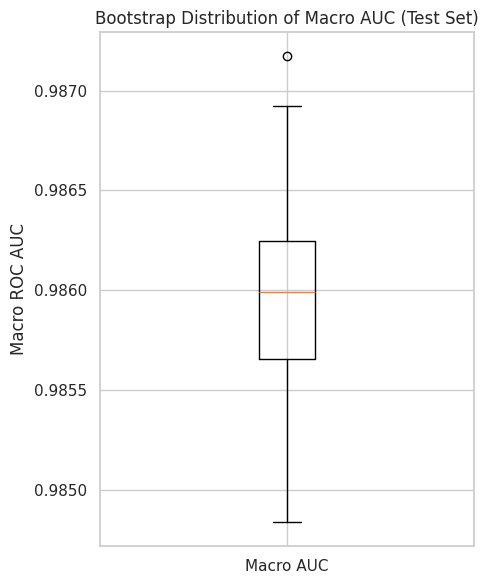

In [12]:
auc_values = np.array([m['auc_macro'] for m in metrics_boot if not np.isnan(m['auc_macro'])])

plt.figure(figsize=(5,6))
plt.boxplot(auc_values, vert=True, labels=['Macro AUC'])
plt.ylabel('Macro ROC AUC')
plt.title('Bootstrap Distribution of Macro AUC (Test Set)')
plt.tight_layout()
plt.show()


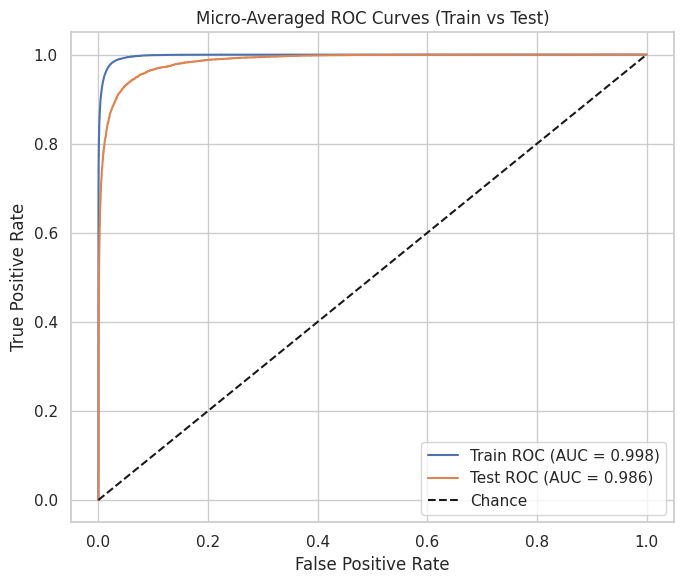

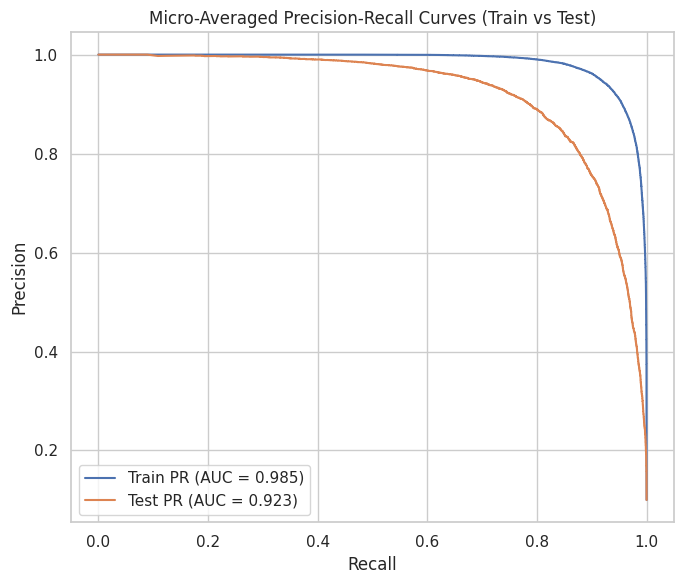

In [13]:
# Binarize labels for micro-averaged curves
y_train_bin = label_binarize(train_y_true, classes=list(range(NUM_CLASSES)))
y_test_bin = label_binarize(test_y_true, classes=list(range(NUM_CLASSES)))

# ROC (micro-average)
train_fpr, train_tpr, _ = roc_curve(y_train_bin.ravel(), train_probs.ravel())
train_roc_auc = auc(train_fpr, train_tpr)

test_fpr, test_tpr, _ = roc_curve(y_test_bin.ravel(), test_probs.ravel())
test_roc_auc = auc(test_fpr, test_tpr)

plt.figure(figsize=(7,6))
plt.plot(train_fpr, train_tpr, label=f'Train ROC (AUC = {train_roc_auc:.3f})')
plt.plot(test_fpr, test_tpr, label=f'Test ROC (AUC = {test_roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Averaged ROC Curves (Train vs Test)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Precision-Recall (micro-average)
train_prec, train_rec, _ = precision_recall_curve(y_train_bin.ravel(), train_probs.ravel())
train_pr_auc = auc(train_rec, train_prec)

test_prec, test_rec, _ = precision_recall_curve(y_test_bin.ravel(), test_probs.ravel())
test_pr_auc = auc(test_rec, test_prec)

plt.figure(figsize=(7,6))
plt.plot(train_rec, train_prec, label=f'Train PR (AUC = {train_pr_auc:.3f})')
plt.plot(test_rec, test_prec, label=f'Test PR (AUC = {test_pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-Averaged Precision-Recall Curves (Train vs Test)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


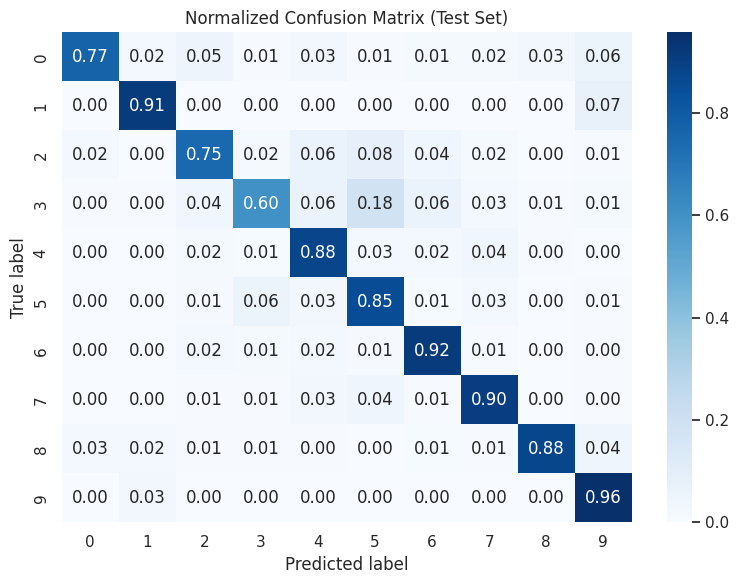

In [14]:
cm = confusion_matrix(test_y_true, test_y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Normalized Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


In [15]:
def compute_saliency_samples(model, dataset, device, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    images_list = []
    labels_list = []
    preds_list = []
    saliency_list = []

    for idx in indices:
        img, label = dataset[idx]
        img = img.to(device)
        img = img.unsqueeze(0)
        img.requires_grad_(True)

        # Forward
        logits = model(img)
        pred_class = logits.argmax(dim=1).item()
        score = logits[0, pred_class]

        # Backward
        model.zero_grad()
        if img.grad is not None:
            img.grad.zero_()
        score.backward()

        grad = img.grad.detach()[0]  # (C,H,W)
        saliency = grad.abs().max(dim=0)[0].cpu().numpy()  # (H,W)

        images_list.append(img.detach().cpu().numpy()[0])
        labels_list.append(label)
        preds_list.append(pred_class)
        saliency_list.append(saliency)

    return indices, np.array(images_list), np.array(labels_list), np.array(preds_list), np.array(saliency_list)


In [16]:
# Compute saliency on a few test samples

num_saliency_samples = 5
indices_s, imgs_s, labels_s, preds_s, saliencies_s = compute_saliency_samples(model, test_dataset, device, num_samples=num_saliency_samples)
print('Saliency computed for test indices:', indices_s)


Saliency computed for test indices: [6252 4684 1731 4742 4521]


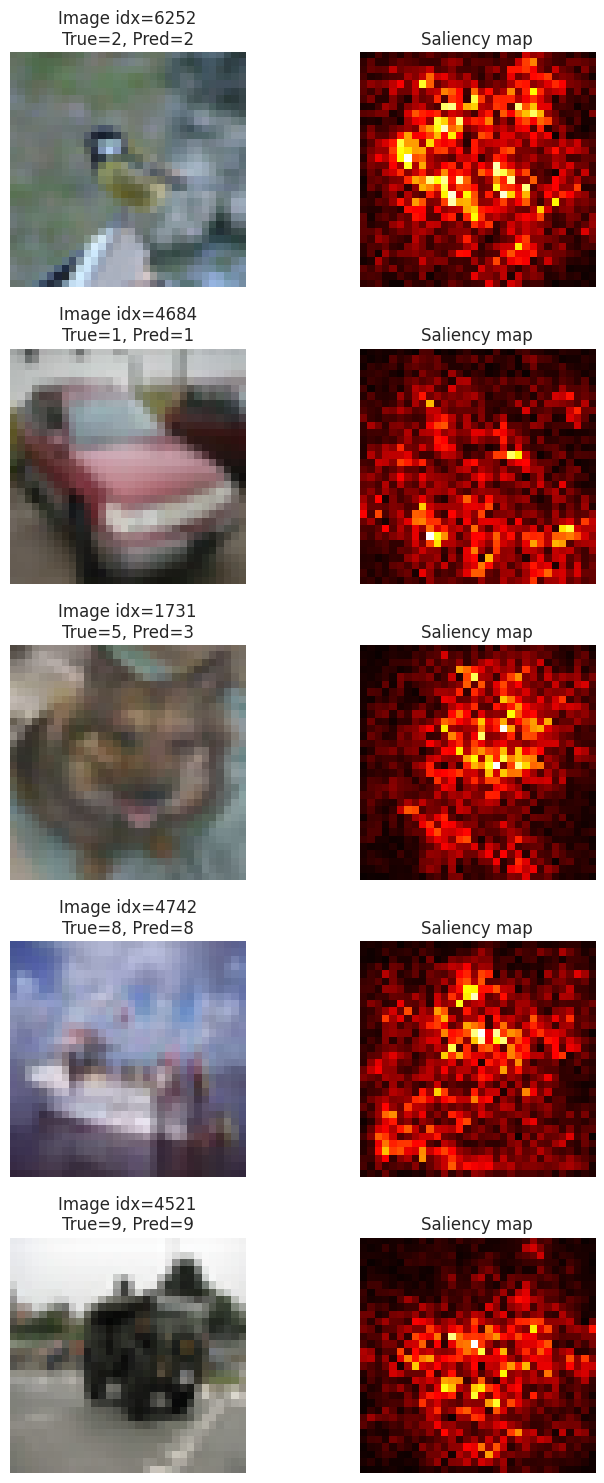

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Plot saliency maps alongside original images (using unnormalized images for display)

# Helper to denormalize CIFAR-10 images for visualization
mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3,1,1)
std = np.array([0.2470, 0.2435, 0.2616]).reshape(3,1,1)

fig, axes = plt.subplots(num_saliency_samples, 2, figsize=(8, 3 * num_saliency_samples))
if num_saliency_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_saliency_samples):
    img = imgs_s[i]
    sal = saliencies_s[i]

    # Denormalize
    img_denorm = (img * std + mean).transpose(1,2,0)
    img_denorm = np.clip(img_denorm, 0, 1)

    ax_img, ax_sal = axes[i]
    ax_img.imshow(img_denorm)
    ax_img.axis('off')
    ax_img.set_title(f'Image idx={indices_s[i]}\nTrue={labels_s[i]}, Pred={preds_s[i]}')

    im = ax_sal.imshow(sal, cmap='hot')
    ax_sal.axis('off')
    ax_sal.set_title('Saliency map')

plt.tight_layout()
plt.show()